
$$
\Large{\textbf{
  Polutant dispersion: deterministic and stochastic models
  }}
$$
\
$$
\large{\text{
  Johannes Löppönen, Arvid Hedin, Elis Graipe
  }}
$$
$$
\ \\
\ \\
\ \\
\ \\
\ \\
$$

# Introduction


The Introduction should provide a *brief description* of the application addressed in the mini-project and of the particular issue(s) to be investigated. This report should be written so that it is accessible to other students in your class.
It is allowed to base the introduction on the mini-project description. In that case, it is important that you reformulate the description so that it becomes shorter and is expressed in **your own words**. However, the description should be understandable without access to the original document (the mini-project paper).


# Approach and method

In this section, you summarise your approach to the problem, and/or the method(s) you've used. Explain briefly the algorithm(s) you have chosen to use. Also explain why these algorithms are appropriate in this context. In this section, you may also show snippets of code (or pseudo code or algorithms). However, the complete code should not be inserted here, but in an Appendix.
If the project consists of several parts, it is usually a good idea that the section has subsections for each part.

You may need to add some mathematical formulas, for example:

Assume that $\textbf y = [y_1,y_2] = [F,R]$ is the state vector, and specify the propensity functions and state-change vectors as below:
$$
\begin{array}{llll}
1.& R \xrightarrow{\alpha} 2R      & v_1 = [0,1],  & w_1 = \alpha y_2\\
2.& R+F\xrightarrow{\beta} 2F      & v_2 = [1,-1], & w_2 = \beta y_1y_2\\
3.& F\xrightarrow{\gamma}\emptyset & v_3 = [-1,0], & w_3 = \gamma y_1
\end{array}
$$

We also assume $a = w_1+w_2+w_3$ and $p_j = \frac{w_j}{a}$ for $j=1,2,3$. Here, $p_j$ is the probability of reaction $j$ to happen. The state-change matrix is defined as

$$
S =
\begin{bmatrix}
0 & 1 \\
1 & -1 \\
-1 & 0
\end{bmatrix}.
$$

The corresponding ODE is
\begin{align*}
&\frac{dF}{dt} = \beta FR - \gamma F \\
&\frac{dR}{dt} = \alpha R -\beta FR
\end{align*}

You may need to add some code snippets, for example:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Constants

N = 2000         
T = 60       
h = 0.1         
D = 0.02
epsilon = 0.1

u = np.array([0.3, 0]) 
num_steps = int(T / h)
checkpoints = [15, 30, 45, 60]

# Task 1

In [3]:
def euler(N,T,h,D,u,num_steps,checkpoints):
    X = np.zeros((N,2))

    t = np.linspace(0,T, num_steps + 1)

    snapshots = {}

    for n in range(0, num_steps+1):
        Z = np.random.randn(N,2)

        X = X + u * h + np.sqrt(2 * D * h) * Z
        
        if round(t[n],1) in checkpoints:
            snapshots[int(t[n])] = X.copy()

    return snapshots

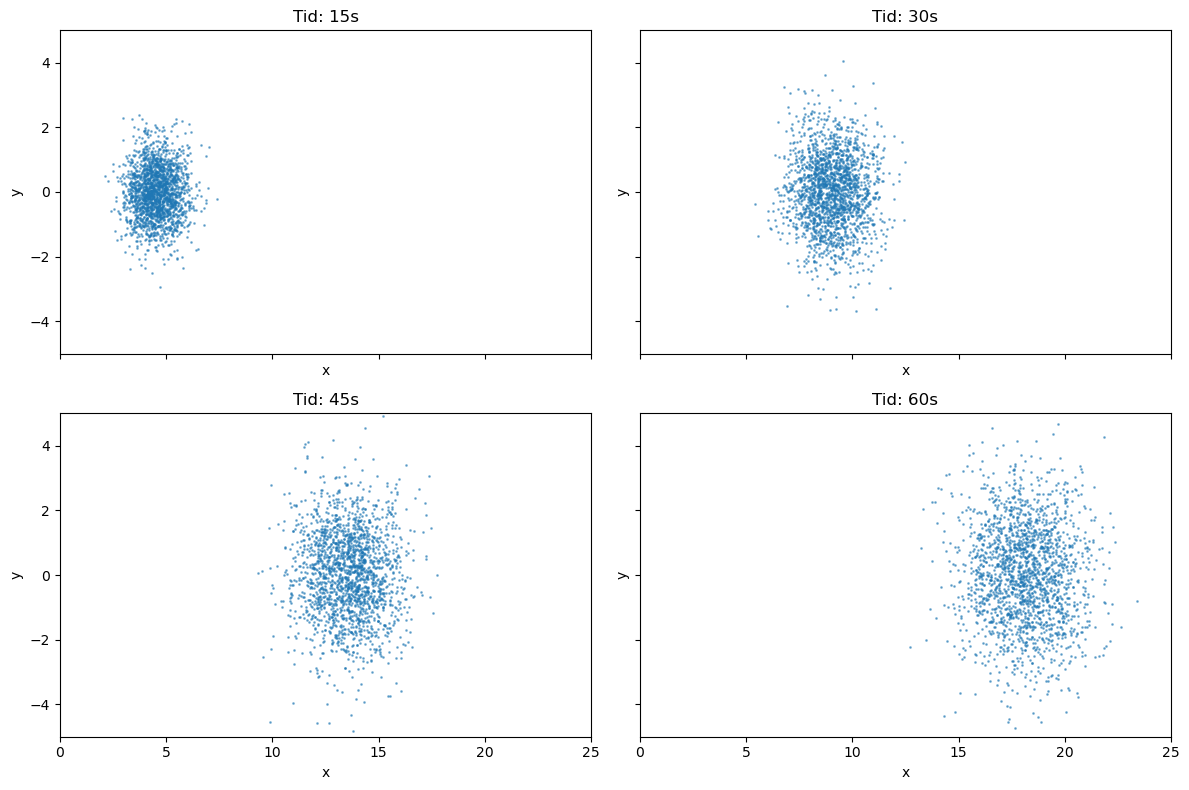

In [4]:
# Plot

snapshots = euler(N,T,h,D,u,num_steps, checkpoints)
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, t in enumerate(checkpoints):
    pos = snapshots[t]
    axes[i].scatter(pos[:, 0], pos[:, 1], s=1, alpha=0.5)
    axes[i].set_title(f"Tid: {t}s")
    axes[i].set_xlim(0, 25)
    axes[i].set_ylim(-5, 5)  
    axes[i].set_xlabel("x")
    axes[i].set_ylabel("y")

plt.tight_layout()
plt.show()

# Task 2

In [5]:
def euler_at_time(N, T, h, D, u):
    # Beräkna hur många steg som krävs för att nå tidpunkten T
    num_steps = int(T / h)
    
    # Initiera positionerna (N partiklar, 2 dimensioner)
    X = np.zeros((N, 2))

    # Förberäkna diffusionskonstanten för att spara beräkningskraft
    diffusion_scale = np.sqrt(2 * D * h)
    drift = u * h

    for _ in range(num_steps):
        Z = np.random.randn(N, 2)
        # Euler-Maruyama steg: X = X + u*dt + sqrt(2*D*dt)*Z
        X = X + drift + diffusion_scale * Z

    return X

def delta_eps(dist, epsilon):
    fac = 1/(2*np.pi*epsilon**2)
    e = np.exp(-dist / (2*epsilon**2))
    return fac * e

def compute_concentration(x_grid, y_grid, snapshot, epsilon):
    N = snapshot.shape[0] #Antalet partiklar vid tiden t
    C = np.zeros(x_grid.shape)

    for k in range(N):
        dist = ((x_grid - snapshot[k,0])**2 + (y_grid - snapshot[k,1])**2)
        C += delta_eps(dist, epsilon)

    return C / N

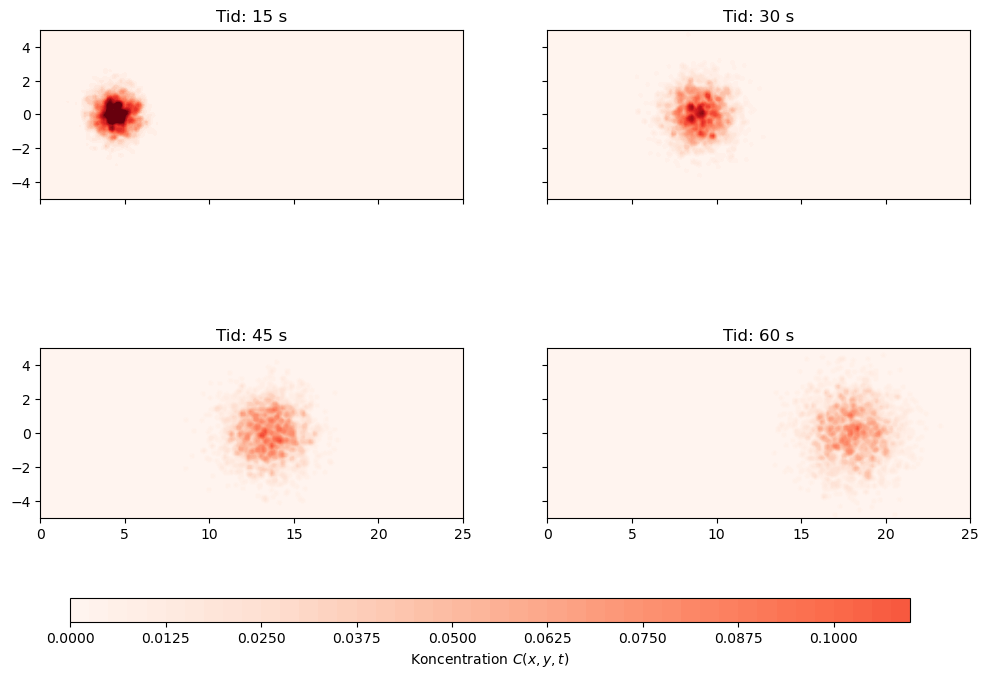

In [6]:
# Setup grid
nx, ny = (200, 100)
x = np.linspace(0, 25, nx)
y = np.linspace(-5, 5, ny)
x_grid, y_grid = np.meshgrid(x, y)

# Plot concentrations
t = np.array([15,30,45,60])
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()
vmin, vmax = 0, 0.2

for i in range(len(t)):
    
    
    X = euler_at_time(N, t[i], h, D, u)
    C = compute_concentration(x_grid, y_grid, X, epsilon)
    contour = axes[i].contourf(x_grid, y_grid, C, levels=50, 
                               cmap='Reds', vmin=vmin, vmax=vmax)
    axes[i].set_title(f"Tid: {t[i]} s")
    axes[i].set_aspect('equal')

fig.subplots_adjust(bottom=0.15)
cbar_ax = fig.add_axes([0.15, 0.08, 0.7, 0.03])
fig.colorbar(contour, cax=cbar_ax, orientation='horizontal', label='Koncentration $C(x,y,t)$')

plt.show()

# Results

In this section, you report the results of each part of the project. To demonstrate that the program works as intended, you include examples of program execution. Present the results in a relevant and appropriate way, like figures, results on the screen etc. If the results contain too much, for example a long list of numbers displayed on the screen, it's recommended to cut it off (and be clear about it in the description). You might also consider making a plot instead of presenting the numbers.
It is important that you convince the reader that you have been able to carry out the mini-project according to the requirements in the mini-project description. You can of course do more than required if you feel it's relevant.




Tables: This is a sample for a table:

<center>

| $h$     | Method A | Method B |
| ---     | ---      | ---      |
| $0.1$   | $1e-2$   | $1e-4$   |
| $0.05$  | $2e-3$   | $4e-6$   |
| $0.025$ | $4e-5$   | $3e-8$   |

</center>




You may plot your necessary figures by executing your code snippets.

In [7]:
N = 1000
X = RandExp(0.5,N)
plt.figure(figsize=(3, 3))
plt.hist(X, bins = 30) 
plt.xlabel('$X$')
plt.ylabel('Frequency')
plt.show()

NameError: name 'RandExp' is not defined

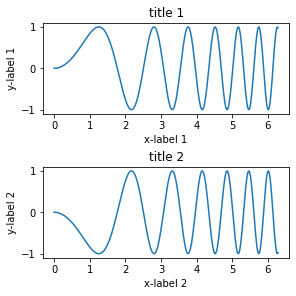

In [ ]:
x = np.linspace(0, 2 * np.pi, 400)
y = np.sin(x ** 2)

fig, axs = plt.subplots(2,1,figsize=(4, 4),constrained_layout = True)
axs[0].plot(x, y)
axs[1].plot(x, -y)
axs[0].set_xlabel('x-label 1')
axs[0].set_ylabel('y-label 1')
axs[0].set_title('title 1')
axs[1].set_xlabel('x-label 2')
axs[1].set_ylabel('y-label 2')
axs[1].set_title('title 2')
plt.show()

Always use `plt.show()` to hide unnecessary output numbers in plt plots. 

# Discussion


In this section you place the additional comments that you find relevant to make, for example, things you might have thought about, things that are unclear, things that would interesting to continue with etc. Some of the mini-projects explicitly contain issues to discuss, and these questions can be addressed in this section.


# References
Here you should include a list of the literature that you use or quote in the report.



# Appendix (if necessary)


Include extended code in an appendix, if any. It might also be other things that do not really fit in the main text that can be included in appendices. For example, it's quite common to see full results in the appendix, and just a few of them in the main text (or just a reference to the appendix in the main text).
